In [11]:
import numpy as np
import matplotlib.pyplot as plt

import preprocessing as prep
import visualization as vis
from filtering import LPF

In [14]:
DATA_DIR = "proxima-hf-6"

SENSORS = {"b_load_1": "LC1 Axial Load",
           "pres_1": "PT1 Combustion Chamber Pressure",
           "pres_2": "PT2 Feedline Pressure",
           "pres_3": "PT3 Injector Pressure",
           "pres_4": "PT4 Ox-Tank Pressure"}

DRIVERS = {0: {"name": "Ox Fill", "False": "Close", "True": "Open"},
            1: {"name": "Ground Vent", "False": "Close", "True": "Open"},
            5: {"name": "Pressurization", "False": "Open", "True": "Close"},
            3: {"name": "Engine Vent", "False": "Close", "True": "Open"},
            6: {"name": "Ignition", "False": "Shutoff", "True": "Ignite"}}

In [15]:
print("Processing events")
prep.process_events_quonkboard(DATA_DIR, DRIVERS)
print("Processing data")
prep.process_data(DATA_DIR, SENSORS)
print("Done!")
# 33
# 6509

Processing events
 contents: 30870
30870
ye
Processing data
Done!


In [18]:
events = prep.import_events(DATA_DIR)
#print(events[57])
#events = [{'secs': '9695', 'elapsed': '00:00', 'delta': '00:00', 'type': 'Ignition', 'info': ''}, {'secs': '10000', 'elapsed': '00:00', 'delta': '00:00', 'type': 'End', 'info': ''}]
labels, data = prep.import_data(DATA_DIR, events)
#print(labels)
        
print(f"HF6 Data Summary \n----------------- \n Sensors: {len(labels) - 1} \n" f" Samples: {len(times)} \n Events:  {len(events)}")

HF6 Data Summary 
----------------- 
 Sensors: 5 
 Samples: 641401 
 Events:  31


In [19]:
ep = vis.EventPlotter(data, events, dpi=100)
lpf = LPF(fs=300, length=101, cutoff=10, window="blackman")

1544.0
463200
475200
[-12.48087 -12.69894 -12.58993 ... -11.9358  -11.49974 -11.49974]


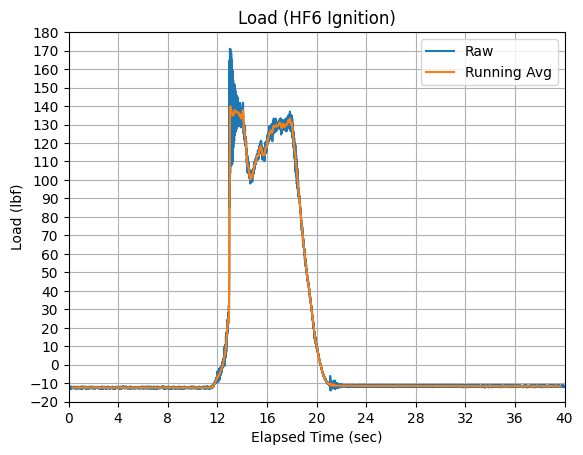

In [22]:
ep.plot(sensor_id=1, event_id=23, duration=40, filter=lpf,
        title="Load (HF6 Ignition)", ylabel="Load (lbf)",
        num_xticks=11, dif_yticks=10)

1544.0
463200
475200
[957.61587 944.30421 930.32698 ... 823.83356 803.69961 800.53818]


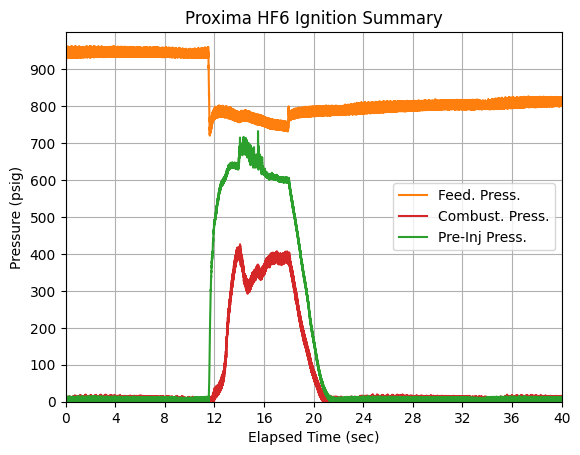

In [24]:
ep.plot(sensor_id=3, event_id=23, duration=40, filter=None,
        title="Proxima HF6 Ignition Summary", ylabel="Pressure (psig)",
        legend="Feed. Press.", num_xticks=11, dif_yticks=100,color="tab:orange")
ep.add_curve(sensor_id=2, event_id=23, duration=40, legend="Combust. Press.",
             color="tab:red")
ep.add_curve(sensor_id=4, event_id=23, duration=40, legend="Pre-Inj Press.",
             color="tab:green")
plt.ylim(0,1000)
plt.yticks(range(0, 901, 100)) 

plt.grid(True)
plt.show()

1544.0
463200
475200
[-12.48087 -12.69894 -12.58993 ... -11.9358  -11.49974 -11.49974]


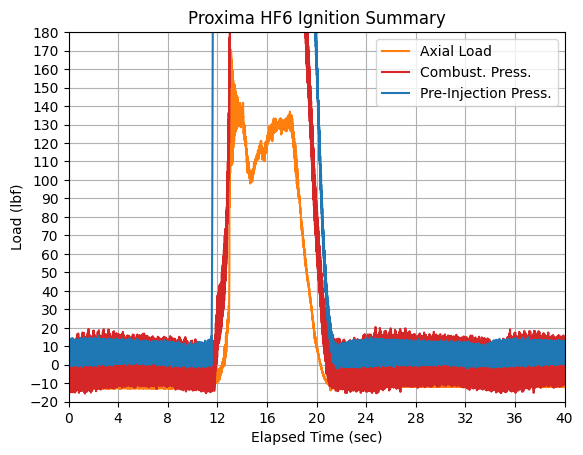

In [25]:
ep.plot(sensor_id=1, event_id=23, duration=40, filter=None,
        title="Proxima HF6 Ignition Summary", ylabel="Load (lbf)",
        legend="Axial Load", num_xticks=11, dif_yticks=10, color="tab:orange",)
ep.add_curve(sensor_id=2, event_id=23, duration=40, legend="Combust. Press.",
             color="tab:red")
ep.add_curve(sensor_id=4, event_id=23, duration=40, legend="Pre-Injection Press.", 
             color="tab:blue")
plt.show()